# Time-Series Forecasting Transformer (TSFT) --- How to use

In [ ]:
"""
NeuralForecast datasets for easy access to ETT, Weather, ECL, Traffic datasets.
"""
!pip install datasetsforecast

In [2]:
import inspect
import torch
import torch.nn as nn

from mohe_forecast.model import TSFTransformer

from mohe_forecast.model.Config import SmallConfig
from mohe_forecast.data_provider.loaders import get_custom_data_loaders
from mohe_forecast.utils import CosineLRDecay, EarlyStopping, LoadBalancingLoss, Trainer
from mohe_forecast.utils.Metrics import eval_forecast_horizons

In [3]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

# count how many trainable weights the model has
def count_parameters(model) -> None:
    total_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of parameters: {total_params}')

In [4]:
from mohe_forecast.data_provider import DataLoaders

dataset_name= 'ETTm1'

df, *_= DataLoaders.load_data(dataset_name)
df.columns

100%|██████████| 314M/314M [00:06<00:00, 47.5MiB/s]


Index(['date', 'HUFL', 'HULL', 'LUFL', 'LULL', 'MUFL', 'MULL', 'OT'], dtype='object')

# Training Backend Setup

In [5]:
use_fused= False
use_flashAttn= False

if device== 'cuda':
    # TF32 computationally more efficient (slightly the same precision of FP32)
    torch.set_float32_matmul_precision('high')
    # enable flash attention
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cudnn.deterministic= True
    # create AdamW optimizer and use the fused version of it is available
    fused_available= 'fused' in inspect.signature(torch.optim.AdamW).parameters
    # fused is a lot faster when it is available and when running on cuda
    use_fused= fused_available
    use_flashAttn= torch.backends.cuda.flash_sdp_enabled()

print(f"Using fused AdamW: {use_fused}; FlashAttention available: {use_flashAttn}")

Using fused AdamW: True; FlashAttention available: True


# --- Encoder --- Weather (d_model= 128)

In [6]:
root_path= './'  # local csv file path
dataset_name= 'weather'
from_csv= False  # If False, read data from NeuralForecast. Otherwise (True), provide a local csv file
btc_size= 128

time_covariates= True
block_size = 672
patch_width= 16
out_width  = 1.5  # 16 * 1.5 = 24
n_outputs  = 96

(
    # Decoders
    dec_train_loader_w, dec_val_loader_w, dec_tds_scaler_w,
    # Encoders
    enc_train_loader_w, enc_val_loader_w, enc_tds_scaler_w,
    # Test -- Decoders/Encoders
    test_loader_w_96, test_loader_w_192, test_loader_w_336, test_loader_w_720,

)= get_custom_data_loaders(
    root_path, dataset_name, from_csv, btc_size, time_covariates, patch_width, block_size, out_width
)

print(f"Weather data -- number of batches (train, val, test)")
print(len(enc_train_loader_w), len(enc_val_loader_w), len(test_loader_w_96))

for x, y, covx, covy in enc_train_loader_w:
    print(x.shape, y.shape, covx.shape, covy.shape)
    break

Weather data -- number of batches (train, val, test)
283 41 82
torch.Size([128, 21, 672]) torch.Size([128, 21, 672]) torch.Size([128, 5, 672]) torch.Size([128, 5, 672])


In [7]:
""" v4
Training with Weather, block_size=672, patch_width=16, width_factor=1.5, batch_size= 128
bias=True in QKV projs, new UnPatch with no activation before ConvTranspose1d, dynamic kernel
in the DWconv, and no biases """



# --- defining a model and training utilities ---
# using pred_len={96, 192, 336, 720} ---> PatchTST-style
# Encoder, RMS, FlashAtt, NO DiffAtt, conv emb, dwconv FFN / FAN MoE, and Forecasting head
channels= 21                #### <------------- multivariate
multi_modal= time_covariates
is_causal= False

config= SmallConfig(
    patch_width=patch_width, channels=channels, n_outputs=n_outputs, width_factor=out_width,
    multi_modal=multi_modal, block_size=block_size
)
model_enc_rms_dw_fan= TSFTransformer.from_config(config).to(device)
count_parameters(model_enc_rms_dw_fan)


if is_causal:
    train_loader= dec_train_loader_w
    val_loader  = dec_val_loader_w
    scaler_obj  = dec_tds_scaler_w
else:
    train_loader= enc_train_loader_w
    val_loader  = enc_val_loader_w
    scaler_obj  = enc_tds_scaler_w

# See https://arxiv.org/abs/2402.02592
# train_loader has size X, so Y epochs have X * Y steps
epochs= 10
steps= len(train_loader) * epochs
learning_rate= 3.2e-3

max_lr= learning_rate
min_lr= 1.2e-4
warmup_steps= steps * 0.1  # 10% of warmup steps
max_steps= steps

optimizer= torch.optim.AdamW(
    model_enc_rms_dw_fan.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=1e-4,
    fused=use_fused
)

# for decreasing learning rate -- the CosineLRDecay is designed to be used per step
scheduler= CosineLRDecay(optimizer, min_lr, max_lr, warmup_steps, max_steps)
# terminate training when the validation loss (per epoch) does not improve
early_stopping= EarlyStopping(patience=5, eps=1e-3)

# See https://arxiv.org/abs/2409.16040
criterion= nn.HuberLoss(reduction='none', delta=2.0)
#criterion= nn.MSELoss(reduction='none')
aux_criterion= LoadBalancingLoss(config.n_experts, config.top_k_experts, alpha=0.02)

trainer= Trainer(
    model_enc_rms_dw_fan, device, train_loader, scaler_obj, val_loader, test_loader_w_96,
    criterion, optimizer, scheduler, aux_criterion, early_stopping, time_covariates,
    do_validation=True, checkpointing=True, filename='v4_tsft_small_weather_checkpoint_p16_1.5pout',
    verbose=True
)

Number of parameters: 2535200


In [ ]:
trainer.train(epochs)

Validating: 100%|██████████| 41/41 [00:03<00:00, 10.67it/s]


Train loss: 24.6468
Valid loss: 15.0969 | dt/epoch: 64047.19ms
======= Epoch 1 Completed =======
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'


Validating: 100%|██████████| 41/41 [00:03<00:00, 10.72it/s]


Train loss: 9.3085
Valid loss: 7.6156 | dt/epoch: 61338.94ms
======= Epoch 2 Completed =======
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'


Validating: 100%|██████████| 41/41 [00:03<00:00, 10.87it/s]


...

Train loss: 6.0440
Valid loss: 1.9683 | dt/epoch: 60668.39ms
======= Epoch 8 Completed =======
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'


Validating: 100%|██████████| 41/41 [00:03<00:00, 10.86it/s]


Train loss: 5.9960
Valid loss: 1.8964 | dt/epoch: 60770.64ms
======= Epoch 9 Completed =======
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'


Validating: 100%|██████████| 41/41 [00:03<00:00, 10.93it/s]


Train loss: 5.9702
Valid loss: 1.8659 | dt/epoch: 60520.15ms
======= Epoch 10 Completed =======
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'
Best Validation Loss: 1.8659 (Epoch 10)
[INFO] Checkpoint saved at 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'


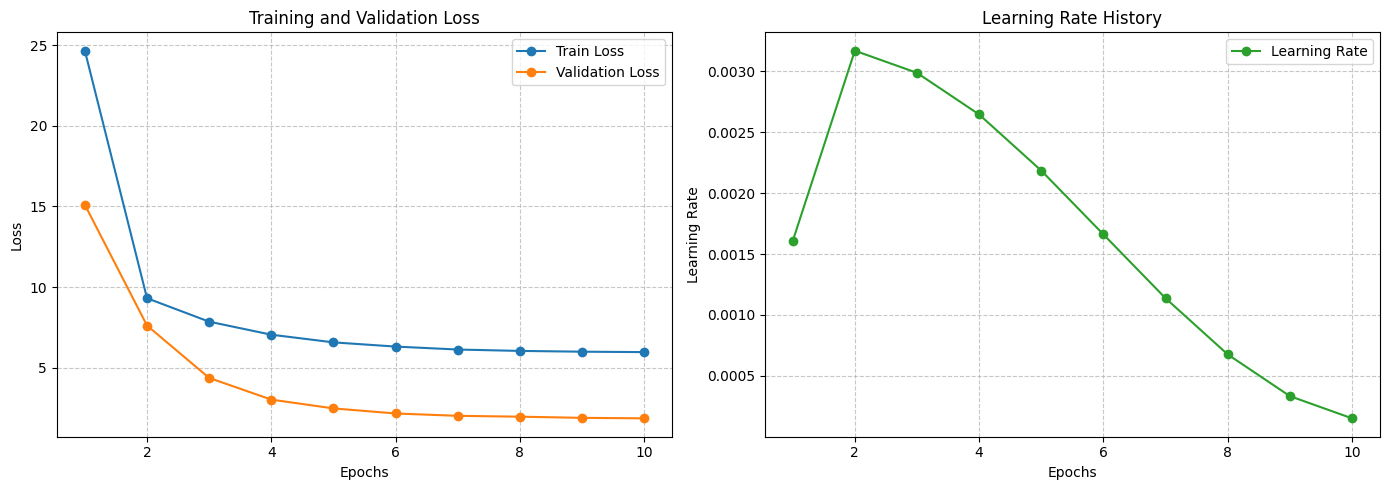

In [ ]:
trainer.plot_results(cut_first_epoch=False, save_charts=False, file_name='training_info')

In [ ]:
epoch, best_val_loss= trainer.load_checkpoint('checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth')

avg_mse, avg_mae= eval_forecast_horizons(
    model_enc_rms_dw_fan, trainer, "Weather", test_loader_w_96, test_loader_w_192,
    test_loader_w_336, test_loader_w_720
)

print(f"\nAverage MSE: {avg_mse:.4f}, Average MAE: {avg_mae:.4f}")

[INFO] Checkpoint loaded from 'checkpoints/v4_tsft_small_weather_checkpoint_p16_1.5pout.pth'. Resuming training with best validation loss of 1.8659.
Weather
Forecast horizon: 96


Testing: 100%|██████████| 82/82 [00:25<00:00,  3.24it/s]


MSE: 0.15373799204826355
MAE: 0.19786858558654785

Forecast horizon: 192


Testing: 100%|██████████| 81/81 [00:48<00:00,  1.66it/s]


MSE: 0.2033604085445404
MAE: 0.24441544711589813

Forecast horizon: 336


Testing: 100%|██████████| 80/80 [01:23<00:00,  1.04s/it]


MSE: 0.2571689188480377
MAE: 0.2858085334300995

Forecast horizon: 720


Testing: 100%|██████████| 77/77 [02:51<00:00,  2.22s/it]


MSE: 0.3380507528781891
MAE: 0.3410590887069702

Average MSE: 0.2381, Average MAE: 0.2673


# End